# Final Project Guide – Insurance Charges Analysis

## Project Scenario
You are a Junior Data Analyst at a health insurance company. The company has provided
you with a dataset of customers’ demographic and health information along with their
medical insurance charges.

Your task is to:
- Clean and prepare the dataset,
- Explore and analyse relationships between features and insurance charges,
- Create meaningful visualisations using Pandas, Matplotlib, and Seaborn,
- Summarise your findings and present them to your manager.

## Learning Outcomes
By the end of the workshop, learners should be able to:
- Load, inspect, and clean a real‑world e‑commerce dataset.
- Engineer simple business metrics (e.g., Revenue).
- Group and summarise data to answer business questions.
- Build clear visualisations with Matplotlib.
- Communicate insights in a business context.

## Dataset Overview
The dataset contains the following key columns:
- age → Age of the insured person.
- sex → Gender of the insured person (male, female).
- bmi → Body Mass Index (an indicator of body fat based on height and weight).
- children → Number of children/dependents covered by the insurance.
- smoker → Whether the person is a smoker (yes, no).
- region → Residential region of the insured (northwest, southeast, etc.).
- charges → Medical insurance cost billed to the individual.

## Business Context:
The company wants to identify which factors influence insurance charges the most (e.g.,
age, BMI, smoking status). These insights will help in pricing policies and advising
customers.


#Project Steps
## Step 1: Import & Inspect the Data

Load the dataset with Pandas:
- Explore with:
  - .head()
  - .info()
  - .shape()
  - .describe()
   - List columns and meaning.

In [71]:
# connecting Colab to google drive:
from google.colab import drive
drive.mount('/content/drive')
# Importing the Python modules/libraries required for this project: pandas, matplotlib and Seaborn.
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [72]:

#loading the csv as a dataframe
df_insurance_not_cleaned = pd.read_csv('/content/drive/MyDrive/insurance.csv', encoding='latin1')



In [73]:
#inspecting data
df_insurance_not_cleaned.head()



,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [74]:
df_insurance_not_cleaned.info()
df_insurance_not_cleaned.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [75]:
#1338 rows, 7 columns
df_insurance_not_cleaned.shape

(1338, 7)


## Step 2: Data Cleaning

Check for missing values and duplicates. Drop duplicates if necessary. Ensure correct
data types.


In [76]:
# Check for missing values
df_insurance_not_cleaned.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [77]:
# Check for duplicates
df_insurance_not_cleaned.duplicated().sum()

np.int64(1)

In [78]:
# Drop duplicates

df_insurance = df_insurance_not_cleaned.drop_duplicates().copy()
df_insurance.duplicated().sum()
#now we can see there are 0 duplicates

np.int64(0)

In [79]:
#check the new size, and we see now we only have 1337 rows
df_insurance.shape

(1337, 7)

In [80]:
# Ensure correct data types
df_insurance.dtypes
#All data types seem to be correct

,0
age,int64
sex,object
bmi,float64
children,int64
smoker,object
region,object
charges,float64



## Step 3: Data Exploration (EDA)

Find average, minimum, and maximum charges. Count smokers vs non-smokers.
Compare charges by gender, region, children.


In [81]:
# Find average, minimum and maximum values from the "charges" column/series
df_insurance['charges'].describe()

,charges
count,1337.000000
mean,13279.121487
std,12110.359656
min,1121.873900
25%,4746.344000
50%,9386.161300
75%,16657.717450
max,63770.428010


In [82]:
#Do a count on the "smoker" column/series to calculate the yes vs no values.
df_insurance['smoker'].value_counts()

,count
smoker,
no,1063
yes,274


In [83]:
# Create bins that group together the values found in the "age", "children" and "region" columns/series
# THen calculate the average of the values found in "charges" for each of these bins in order to see
# the differences between charges by insuree age, number of children of insuree and regions of insurance.
print("Average charges by region:")
display(df_insurance.groupby('region')['charges'].mean().sort_values(ascending=False))

Average charges by region:


,charges
region,
southeast,14735.411438
northeast,13406.384516
northwest,12450.840844
southwest,12346.937377


In [84]:
# Create age groups
# Define age bins and labels
age_bins = [18, 30, 50, 65]
#minimum age is 18, maximum is 64
age_labels = ['Young', 'Middle-aged', 'Senior']
df_insurance['age_group'] = pd.cut(df_insurance['age'], bins=age_bins, labels=age_labels, right=False)

print("\nAverage charges by age group:")
display(df_insurance.groupby('age_group', observed=False)['charges'].mean().sort_values(ascending=False))


Average charges by age group:


,charges
age_group,
Senior,17902.552070
Middle-aged,13123.592001
Young,9200.619154


In [85]:
# Create children groups
# Define children bins and labels
children_bins = [-1, 0, 2, df_insurance['children'].max()]
children_labels = ['0 Children', '1-2 Children', '3+ Children']
df_insurance['children_group'] = pd.cut(df_insurance['children'], bins=children_bins, labels=children_labels, right=True)

print("\nAverage charges by number of children:")
display(df_insurance.groupby('children_group', observed=False)['charges'].mean().sort_values(ascending=False))


Average charges by number of children:


,charges
children_group,
3+ Children,14576.000129
1-2 Children,13727.934343
0 Children,12384.695344


In [86]:
#checking the dataframe
df_insurance

,age,sex,bmi,children,smoker,region,charges,age_group,children_group
0,19,female,27.900,0,yes,southwest,16884.92400,Young,0 Children
1,18,male,33.770,1,no,southeast,1725.55230,Young,1-2 Children
2,28,male,33.000,3,no,southeast,4449.46200,Young,3+ Children
3,33,male,22.705,0,no,northwest,21984.47061,Middle-aged,0 Children
4,32,male,28.880,0,no,northwest,3866.85520,Middle-aged,0 Children
...,...,...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830,Senior,3+ Children
1334,18,female,31.920,0,no,northeast,2205.98080,Young,0 Children
1335,18,female,36.850,0,no,southeast,1629.83350,Young,0 Children
1336,21,female,25.800,0,no,southwest,2007.94500,Young,0 Children



## Step 4: Data Transformation

Create bmi_category (Underweight, Normal, Overweight, Obese). Create age_group
(Young, Middle-aged, Senior).


In [87]:

# Currently the CSV spreadsheet data which you've turned into a Pandas Dataframe contains the following
# columns: "age", "sex", "bmi", "children", "smoker", "region" and "charges". You need to create a new
# column/series in the Pandas Dataframe which is called "bmi_category" which groups up the values in the
# "bmi" column into four groups: Underweight, Normal, Overweight, Obese. You can make up the value ranges
# that would fit into each of the groups yourself or look up the actually bmi values that fit into these
# categories.
bmi_bins = [0, 18.5, 24.9, 29.9, df_insurance['bmi'].max()]
bmi_labels = ['Underweight', 'Normal', 'Overweight', 'Obese']
df_insurance['bmi_category'] = pd.cut(df_insurance['bmi'], bins=bmi_bins, labels=bmi_labels, right=True)

print("\nAverage charges by BMI category:")
display(df_insurance.groupby('bmi_category', observed=False)['charges'].mean().sort_values(ascending=False))

# Now you must also create another new column called "age group" and do the same as you did above but this
# time with the age values in the "age" column. Split these into three groups: Young, Middle-aged, Senior.
#Andreas comment- THIS WAS DONE IN PREVIOUS CELL


Average charges by BMI category:


,charges
bmi_category,
Obese,15510.915636
Overweight,11006.809989
Normal,10404.900084
Underweight,8657.620652



## Step 5: Visualisation with `Matplotlib`

Create bar chart (average charges by region), line chart (average charges by age), pie
chart (smoker vs non-smoker).


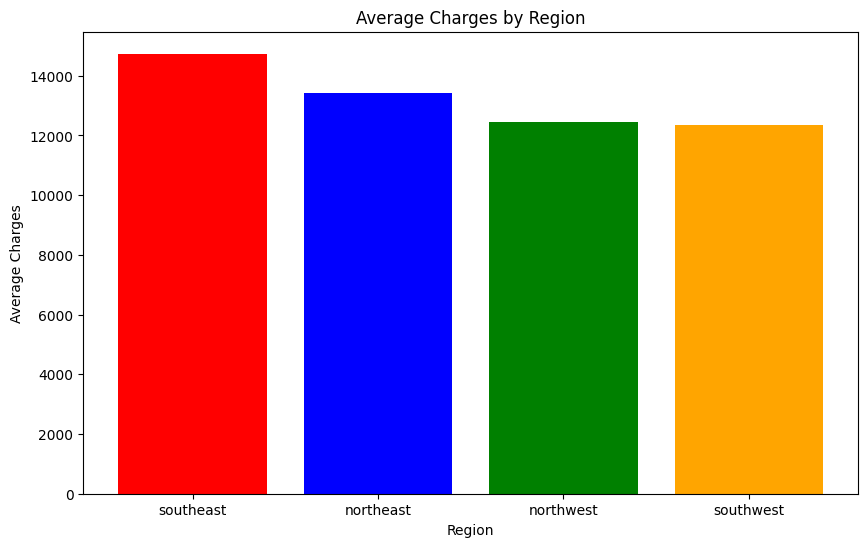

In [88]:

# Create a bar chart showing average charges by region with MatPlotLib
grouped_region = df_insurance.groupby('region')['charges'].mean().sort_values(ascending=False)
plt.figure(figsize=(10, 6))
plt.bar(grouped_region.index, grouped_region.values,color=['red','blue','green','orange'])
plt.title('Average Charges by Region')
plt.xlabel('Region')
plt.ylabel('Average Charges')
plt.show()



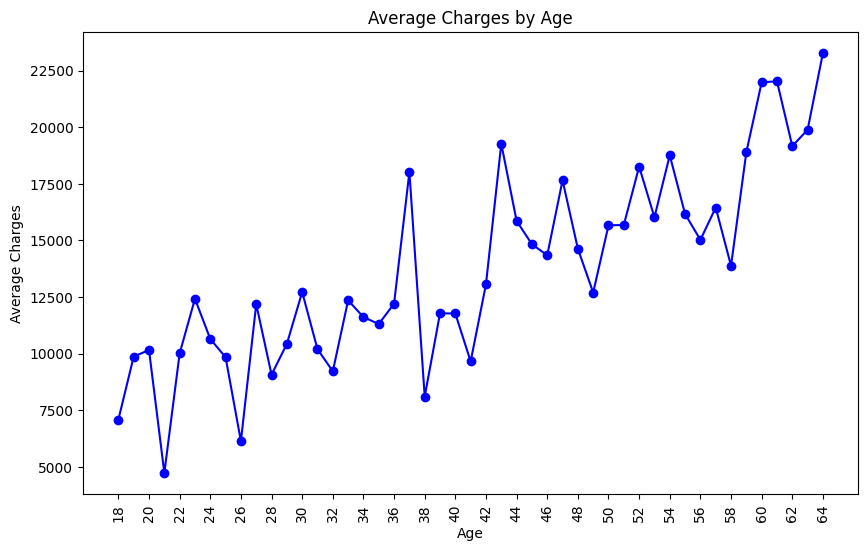

In [89]:
# Create a line chart showing average charges by age with MatPlotLib
grouped_age = df_insurance.groupby('age')['charges'].mean()

#create even ages index for x axis:
even_ages = [age for age in grouped_age.index if age % 2 == 0]
plt.figure(figsize=(10, 6))
plt.plot(grouped_age.index, grouped_age.values, marker='o', linestyle='-', color='b')
plt.xticks(ticks= even_ages,rotation=90)
plt.title('Average Charges by Age')
plt.xlabel('Age')
plt.ylabel('Average Charges')
plt.show()

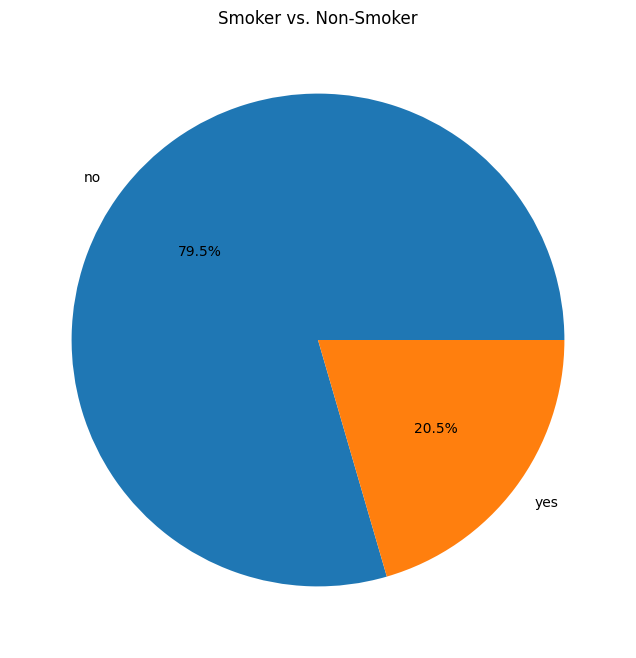

In [90]:
# Create a pie chart showing average the divide of smokers vs. non-smokers with MatPlotLib
smoker_counts = df_insurance['smoker'].value_counts()
plt.figure(figsize=(8, 8))
plt.pie(smoker_counts.values, labels=smoker_counts.index, autopct='%1.1f%%')
plt.title('Smoker vs. Non-Smoker')
plt.show()


## Step 6: Visualisation with `Seaborn`

Create histogram (charges), boxplot (smoker vs non-smoker), scatter plot (BMI vs
charges), heatmap (correlations).


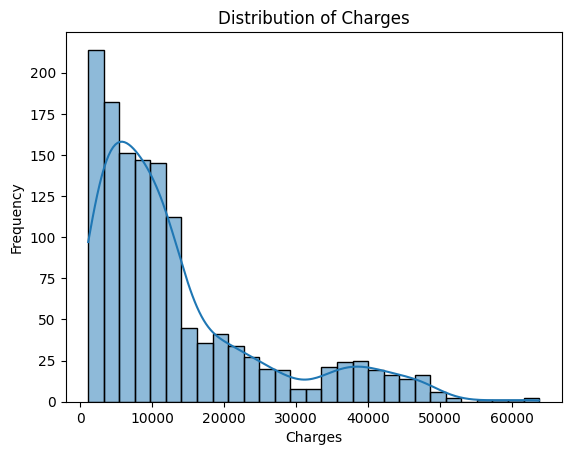

In [91]:

# Use Seaborn to create histogram showing the distribute of the charges column
sb.histplot(df_insurance['charges'], kde=True)
plt.title('Distribution of Charges')
plt.xlabel('Charges')
plt.ylabel('Frequency')
plt.show()


The histogram is right skewed

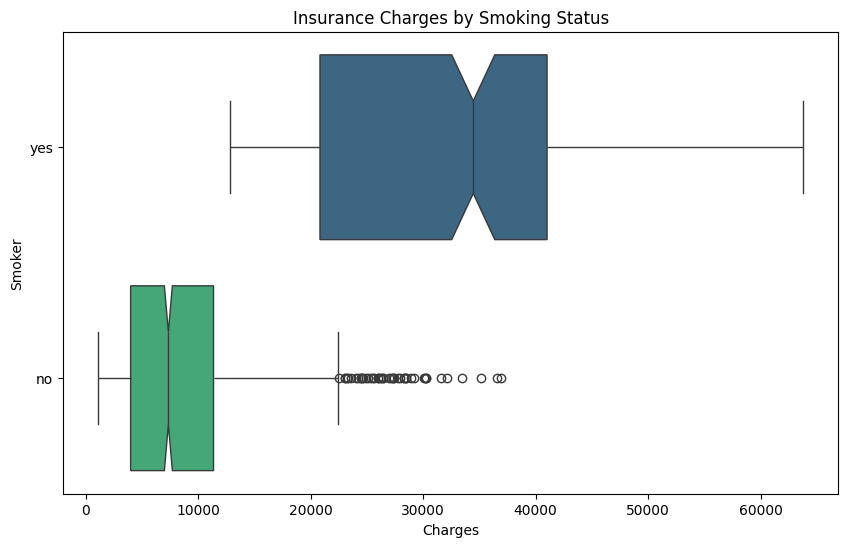

In [97]:
plt.figure(figsize=(10, 6))
sb.boxplot(x='charges', y='smoker', data=df_insurance, palette='viridis', hue='smoker', notch=True, legend=False)
plt.title('Insurance Charges by Smoking Status')
plt.xlabel('Charges')
plt.ylabel('Smoker')
plt.show()

/tmp/ipykernel_10403/3910261560.py:3: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sb.scatterplot(x='charges', y='bmi', data=df_insurance, palette='viridis')


Text(0.5, 1.0, 'BMI vs. Charges')

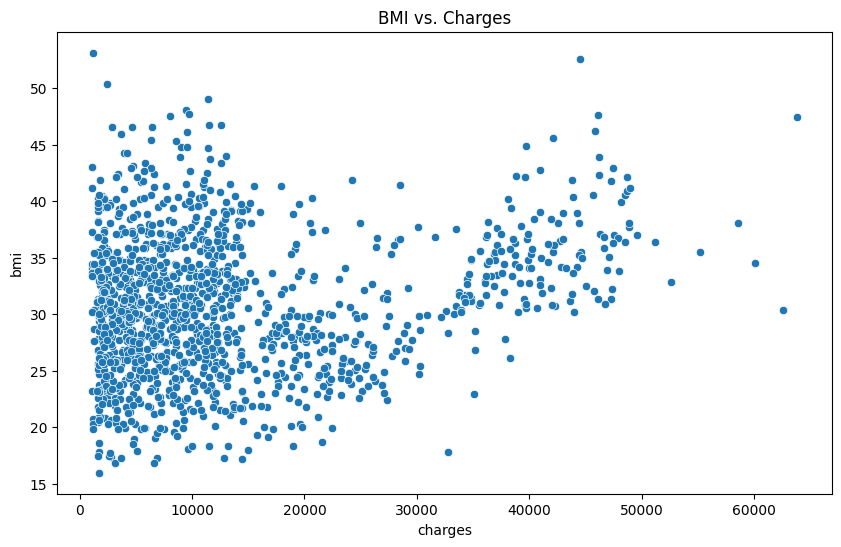

In [93]:
# Use Seaborn to create scatter plot show the Y-axis BMI values vs X-Axis charges values)
plt.figure(figsize=(10, 6))
sb.scatterplot(x='charges', y='bmi', data=df_insurance, palette='viridis')
plt.title('BMI vs. Charges')



Text(0.5, 1.0, 'BMI vs. Charges')

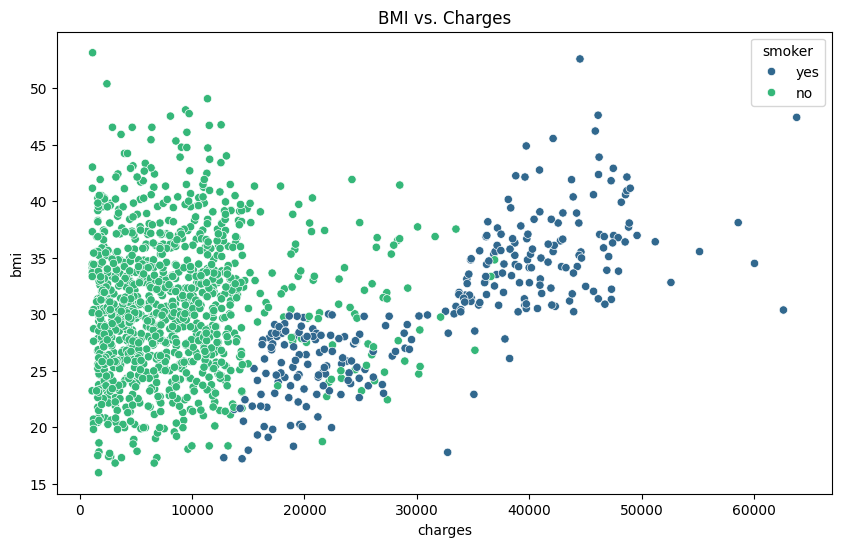

In [94]:
#plotting the same graph but colour coding non smokers and smokers
plt.figure(figsize=(10, 6))
sb.scatterplot(x='charges', y='bmi', data=df_insurance, hue = 'smoker',palette='viridis')
plt.title('BMI vs. Charges')

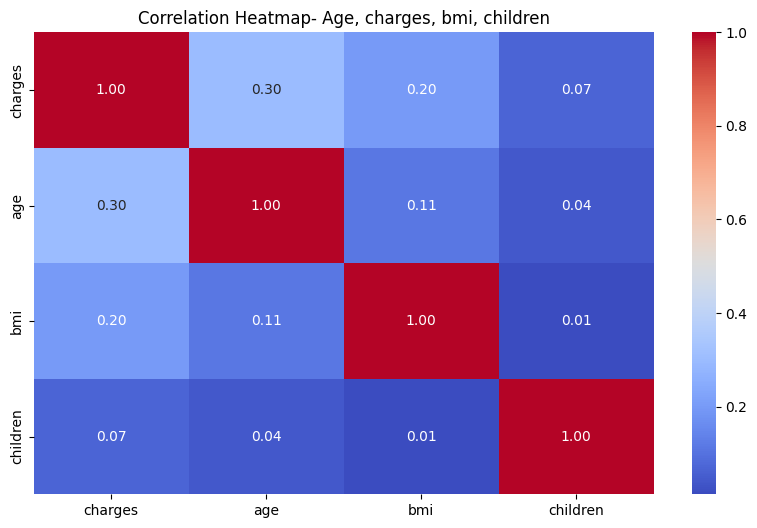

In [95]:
# Use Seaborn to create a heatmap showing correlations between charges and age, bmi and children
corr_matrix = df_insurance[['charges', 'age', 'bmi', 'children']].corr()
plt.figure(figsize=(10, 6))
sb.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap- Age, charges, bmi, children')
plt.show()



## Step 7: Business Insights & Reflection

Summarise findings:
- smokers vs non-smokers
- BMI effect,
- age impact
- regional differences.

Reflection question:
- If you were advising the company, which three factors
are the strongest drivers of charges and why?

###Write your report in the cell below:

## Report on findings:

###Smokers vs Non-Smokers

- The boxplot shows that the median value of charges for smokers is much higher than it is for non smokers.
- Addtionally, in the 2nd scatter plot for BMI vs charges, we can see quite clearly that regardless of BMI, smokers had much higher values of charges.

###BMI effect

- Looking at the scatterplot for BMI vs charges, while we can see a positive correlation between high BMI and higher charges, there are many points concentrated to the left of the plot, and when digging deeper, the 2nd scatterplot showed that almost all these plot points are for non smokers
- This suggests that smokers with a high BMI are more likely to have higher charges, but this isn't necessarily the case for non smokers.
- This might be why in the correlation matrix, the value for charges and BMI is only 0.2.

###Age Impact

- Looking at age, the line chart does trend upwards, i.e. the average charges increases as age increases, with one notable outlier being at age 37.
- In the correlation matrix, the value for charges and age is 0.3, a higher value than for bmi and children.

###Regional Differences

*   The average charges in the South East are highest, whereas the South West has the lowest average charges.
*   Further analysis might be needed, for example, we know that smoking vs not smoking has a large impact, are there a higher proportion of smokers in the South East? Even if this analysis might fall out of the scope of the project, it would be interesting to explore.

##Reflection Question:

Looking at my analysis, I would say that the three biggest drivers of charges, in order, are Smoker vs. Non smoker, Age, BMI in that order. But I would stress that smoker vs non smoker has a much bigger impact than the other two, so this should be the main focus.









# Deliverables
By the end of this project, you should produce:
1. A cleaned and prepared dataset ready for analysis.
2. Pandas analysis outputs (groupby, aggregations, new columns).
3. Visualisations with Matplotlib and Seaborn.
4. A short written summary of your findings. (Please write this in the cell above)
5. A presentation to introduce the project, explain your steps, and highlight insights.
